In [ ]:
📘 CUSTOMER CHURN ANALYSIS

### 1. Import Libraries

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### Note:
##### These libraries help us:
 
- pandas → work with data

- numpy → math operations

- matplotlib & seaborn → create graphs

### 2. Load Dataset

In [31]:
df = pd.read_csv("telecom_churn_data.csv")
df.head()

,year,customer_id,phone_no,gender,age,no_of_days_subscribed,multi_screen,mail_subscribed,weekly_mins_watched,minimum_daily_mins,maximum_daily_mins,weekly_max_night_mins,videos_watched,maximum_days_inactive,customer_support_calls,churn
0,2015,100198,409-8743,Female,36,62,no,no,148.35,12.2,16.81,82,1,4.0,1,0.0
1,2015,100643,340-5930,Female,39,149,no,no,294.45,7.7,33.37,87,3,3.0,2,0.0
2,2015,100756,372-3750,Female,65,126,no,no,87.30,11.9,9.89,91,1,4.0,5,1.0
3,2015,101595,331-4902,Female,24,131,no,yes,321.30,9.5,36.41,102,4,3.0,3,0.0
4,2015,101653,351-8398,Female,40,191,no,no,243.00,10.9,27.54,83,7,3.0,1,0.0


- This loads the dataset and shows first 5 rows.

### 3. Basic Information

In [32]:
df.shape
df.info()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   year                    2000 non-null   int64  
 1   customer_id             2000 non-null   int64  
 2   phone_no                2000 non-null   object 
 3   gender                  1976 non-null   object 
 4   age                     2000 non-null   int64  
 5   no_of_days_subscribed   2000 non-null   int64  
 6   multi_screen            2000 non-null   object 
 7   mail_subscribed         2000 non-null   object 
 8   weekly_mins_watched     2000 non-null   float64
 9   minimum_daily_mins      2000 non-null   float64
 10  maximum_daily_mins      2000 non-null   float64
 11  weekly_max_night_mins   2000 non-null   int64  
 12  videos_watched          2000 non-null   int64  
 13  maximum_days_inactive   1972 non-null   float64
 14  customer_support_calls  2000 non-null   

Index(['year', 'customer_id', 'phone_no', 'gender', 'age',
       'no_of_days_subscribed', 'multi_screen', 'mail_subscribed',
       'weekly_mins_watched', 'minimum_daily_mins', 'maximum_daily_mins',
       'weekly_max_night_mins', 'videos_watched', 'maximum_days_inactive',
       'customer_support_calls', 'churn'],
      dtype='object')

- shape → number of rows and columns

- info() → data types

- columns → column names

### 4.Drop Irrelevant Columns

In [33]:
df.drop(columns=['customer_id','phone_no','year'], inplace=True)

Reason:

* customer_id → unique identifier
* phone_no → not useful
* year → constant


### 5. Check Missing Values

In [34]:
df.isnull().sum()

gender                    24
age                        0
no_of_days_subscribed      0
multi_screen               0
mail_subscribed            0
weekly_mins_watched        0
minimum_daily_mins         0
maximum_daily_mins         0
weekly_max_night_mins      0
videos_watched             0
maximum_days_inactive     28
customer_support_calls     0
churn                     35
dtype: int64

##### Note:
- This checks if any values are missing.

- If missing values exist:

In [42]:
# Fill categorical column with mode
df['gender'] = df['gender'].fillna(df['gender'].mode()[0])


In [43]:
# Fill numeric column with median
df['maximum_days_inactive'] = df['maximum_days_inactive'].fillna(
    df['maximum_days_inactive'].median()
)

In [44]:
# Drop rows where churn (target) is missing
df = df.dropna(subset=['churn'])

### 6. Separate Categorical & Numerical Columns

In [45]:
categorical_cols = df.select_dtypes(include='object').columns
numerical_cols = df.select_dtypes(exclude='object').columns

categorical_cols
numerical_cols

Index(['age', 'no_of_days_subscribed', 'weekly_mins_watched',
       'minimum_daily_mins', 'maximum_daily_mins', 'weekly_max_night_mins',
       'videos_watched', 'maximum_days_inactive', 'customer_support_calls',
       'churn'],
      dtype='object')

#### Note:
- We separate text columns and number columns.

### 7. Summary Statistics
##### For Number Columns

In [47]:
df[numerical_cols].describe()

,age,no_of_days_subscribed,weekly_mins_watched,minimum_daily_mins,maximum_daily_mins,weekly_max_night_mins,videos_watched,maximum_days_inactive,customer_support_calls,churn
count,1965.000000,1965.000000,1965.000000,1965.000000,1965.000000,1965.000000,1965.000000,1965.000000,1965.000000,1965.000000
mean,38.697710,99.750636,269.894275,10.198677,30.588570,100.453944,4.490585,3.246310,1.544529,0.133333
std,10.196352,39.887889,80.578226,2.771632,9.132183,19.545277,2.488576,0.800581,1.310958,0.340021
min,18.000000,1.000000,0.000000,0.000000,0.000000,42.000000,0.000000,0.000000,0.000000,0.000000
25%,32.000000,72.000000,218.250000,8.400000,24.740000,87.000000,3.000000,3.000000,1.000000,0.000000
50%,37.000000,99.000000,269.550000,10.200000,30.550000,101.000000,4.000000,3.000000,1.000000,0.000000
75%,44.000000,127.000000,324.000000,12.000000,36.720000,114.000000,6.000000,4.000000,2.000000,0.000000
max,82.000000,243.000000,526.200000,20.000000,59.640000,175.000000,19.000000,6.000000,9.000000,1.000000


- Shows average, minimum, maximum etc.

##### For categorical:


In [48]:
for col in categorical_cols:
    print(df[col].value_counts())
    print("-----------------")

gender
Male      1056
Female     909
Name: count, dtype: int64
-----------------
multi_screen
no     1769
yes     196
Name: count, dtype: int64
-----------------
mail_subscribed
no     1404
yes     561
Name: count, dtype: int64
-----------------


### 8. EDA Visualizations
#### Churn Distribution

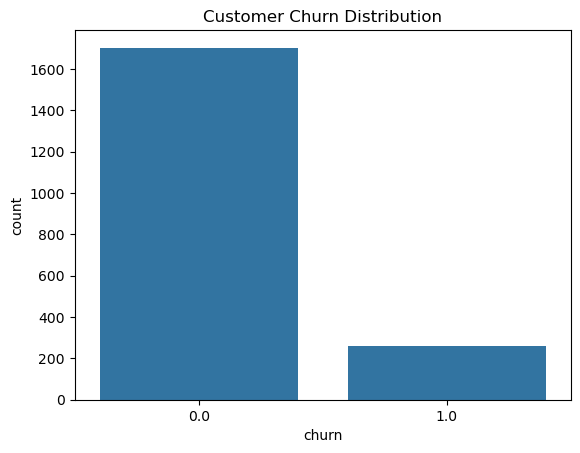

In [49]:
sns.countplot(x='churn', data=df)
plt.title("Customer Churn Distribution")
plt.show()

- 0 = Customer stayed
- 1 = Customer left

#### Days Subscribed vs Churn


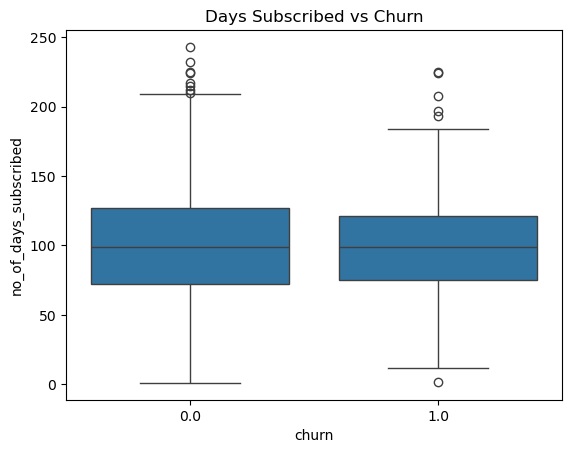

In [50]:
sns.boxplot(x='churn', y='no_of_days_subscribed', data=df)
plt.title("Days Subscribed vs Churn")
plt.show()

#### Weekly Minutes Watched vs Churn

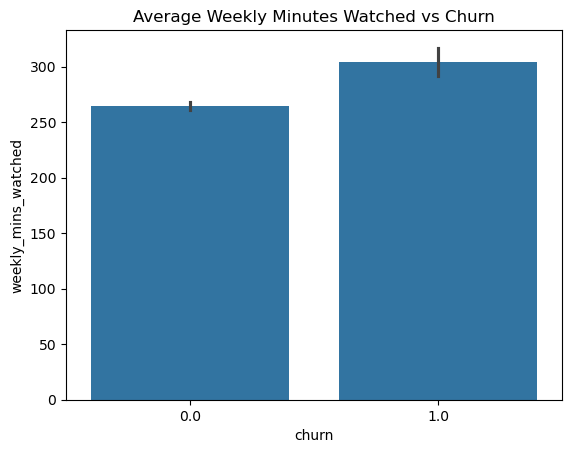

In [51]:
sns.barplot(x='churn', y='weekly_mins_watched', data=df)
plt.title("Average Weekly Minutes Watched vs Churn")
plt.show()

#### Maximum Inactive Days vs Churn (Histogram)

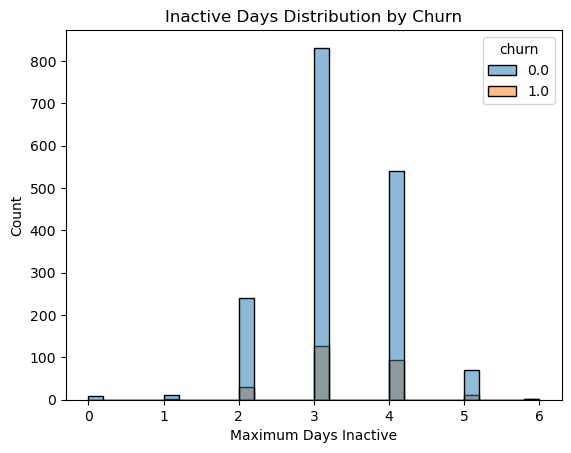

In [52]:
sns.histplot(data=df, x='maximum_days_inactive', hue='churn', bins=30)
plt.title("Inactive Days Distribution by Churn")
plt.xlabel("Maximum Days Inactive")
plt.ylabel("Count")
plt.show()

### Support Calls vs Churn


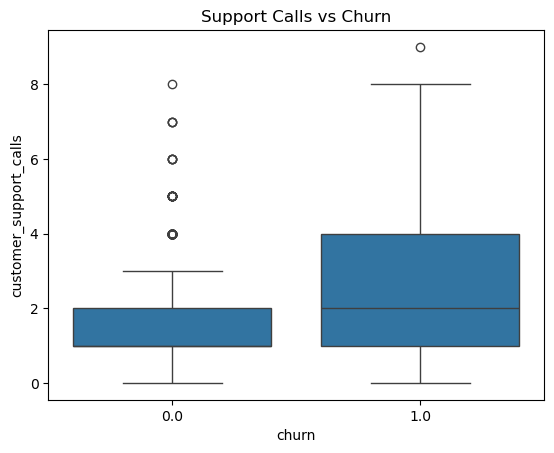

In [53]:
sns.boxplot(x='churn', y='customer_support_calls', data=df)
plt.title("Support Calls vs Churn")
plt.show()

### Pie Chart

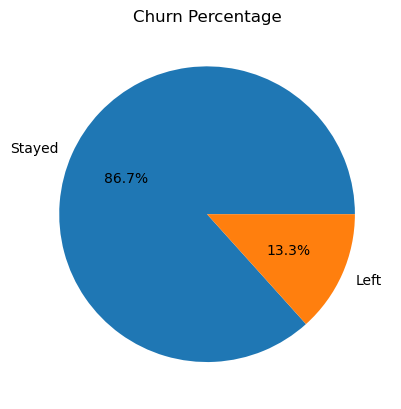

In [54]:
churn_counts = df['churn'].value_counts()

plt.pie(churn_counts, labels=['Stayed','Left'], autopct='%1.1f%%')
plt.title("Churn Percentage")
plt.show()

### 9. Encoding

In [55]:
df = pd.get_dummies(df, drop_first=True)

### 10. Model Building

In [58]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = df.drop('churn', axis=1)
y = df['churn']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Model
model = LogisticRegression(max_iter=3000)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.8804071246819338


#### Final Conclusion 

- The analysis shows that customer inactivity, lower subscription days, and higher support calls increase the likelihood of churn. Engagement plays a major role in customer retention. The Logistic Regression model achieved approximately 88% accuracy, indicating strong predictive performance.
